---
# ***1.histplot — distribution with more control than matplotlib hist***
---

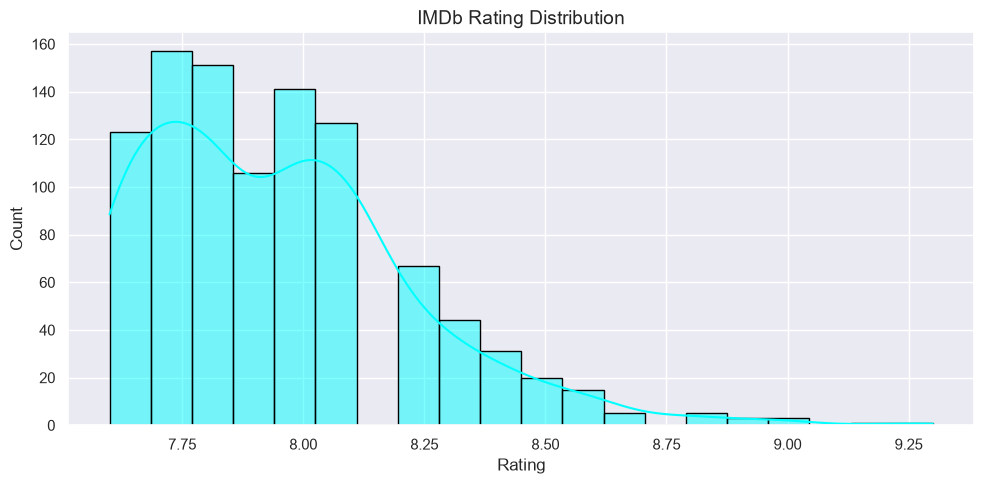

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("imdb_top_1000_cleaned.csv")
sns.set_theme(style='darkgrid')

fig, ax=plt.subplots(figsize=(10,5))
sns.histplot(data=df, x='IMDB_Rating', bins=20, kde=True, color='cyan', edgecolor='black', ax=ax)
ax.set_title("IMDb Rating Distribution", fontsize=14)
ax.set_xlabel("Rating")

plt.tight_layout()
plt.show()

---
# ***2. boxplot — spread and outliers of a variable***
---

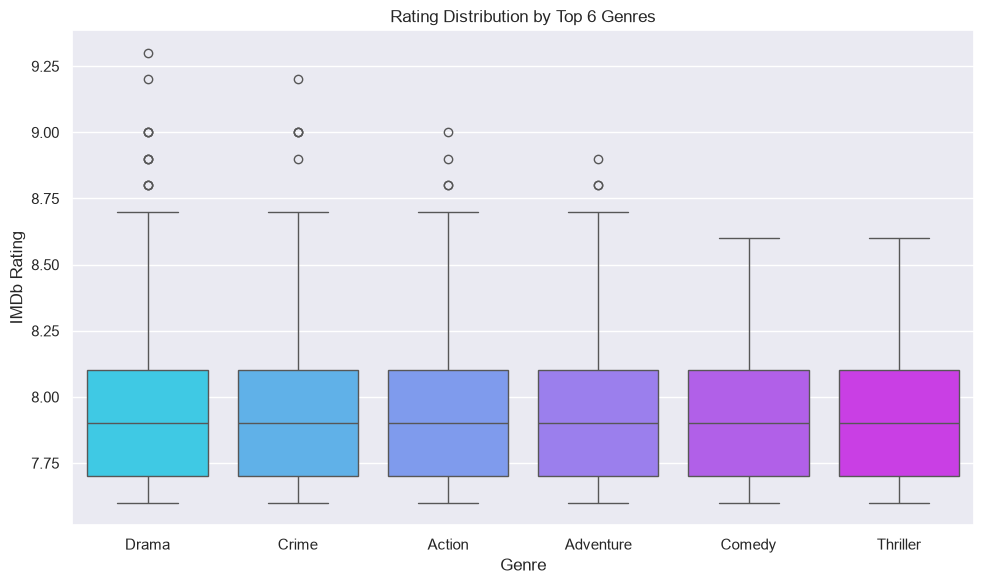

In [20]:
df_genres = df.assign(Genre=df['Genre'].str.split(', ')).explode('Genre')
top_genres = df_genres['Genre'].value_counts().head(6).index
df_top = df_genres[df_genres['Genre'].isin(top_genres)]
fig, ax=plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_top, x='Genre', y='IMDB_Rating', hue='Genre', palette='cool', legend=False, ax=ax)
ax.set_title('Rating Distribution by Top 6 Genres')
ax.set_xlabel('Genre')
ax.set_ylabel('IMDb Rating')
plt.tight_layout()
plt.show()

---
# ***3.heatmap — correlation matrix***
---

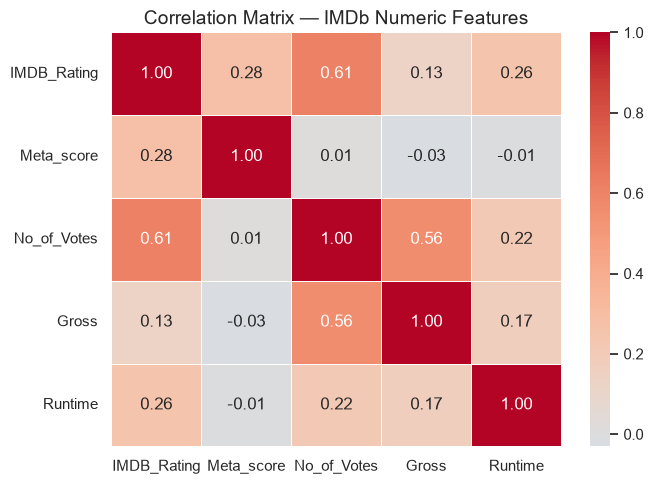

In [3]:
numeric_cols = df[['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross', 'Runtime']].dropna()
corr_matrix = numeric_cols.corr()
fig, ax=plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — IMDb Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

---
# ***4.pairplot — scatter matrix of all numeric columns***
---

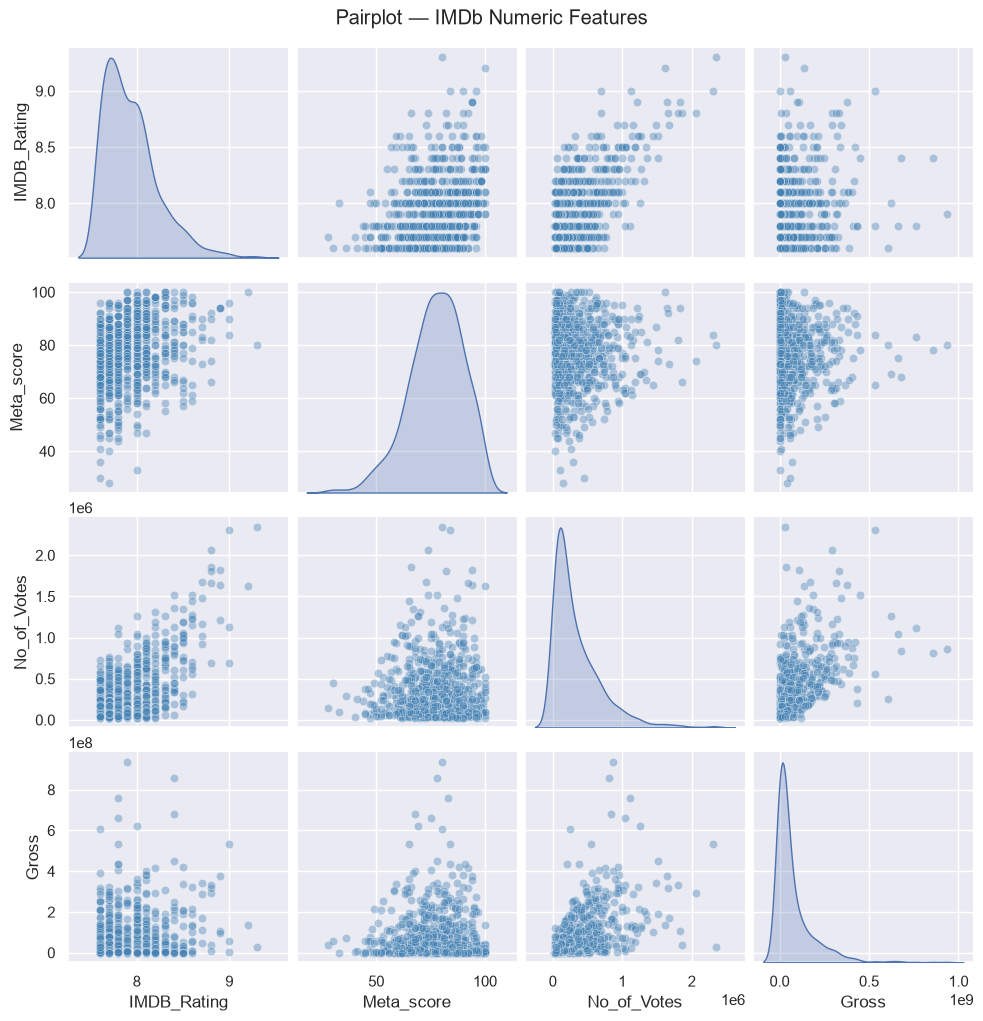

In [4]:
df_pair = df[['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']].dropna()
sns.pairplot(df_pair, diag_kind='kde', plot_kws={'alpha' : 0.4, 'color' : 'steelblue'})
plt.suptitle('Pairplot — IMDb Numeric Features', y=1.02)
plt.show()

---
# ***5.barplot — mean with confidence interval***
---

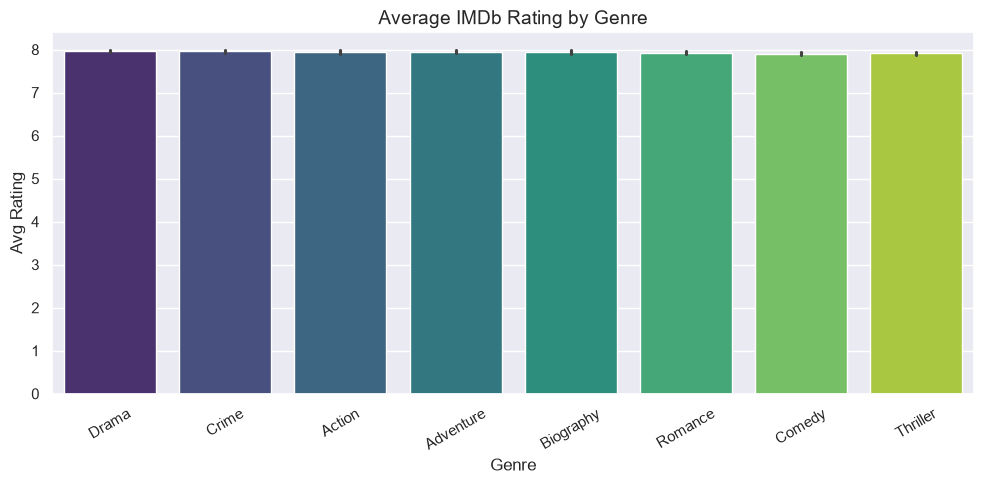

In [6]:
df_genres = df.assign(Genre=df['Genre'].str.split(', ')).explode('Genre')
top_genres = df_genres['Genre'].value_counts().head(8).index
df_top = df_genres[df_genres['Genre'].isin(top_genres)]
fig, ax=plt.subplots(figsize=(10, 5))
sns.barplot(data=df_top, x='Genre', y='IMDB_Rating', hue='Genre', palette='viridis', legend=False, ax=ax)
ax.set_title('Average IMDb Rating by Genre', fontsize=14)
ax.set_xlabel('Genre')
ax.set_ylabel('Avg Rating')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

---
# ***Seaborn Mini Exercises***
---

---
# ***Exercise 1 — Runtime histplot: where does it cluster?***
---

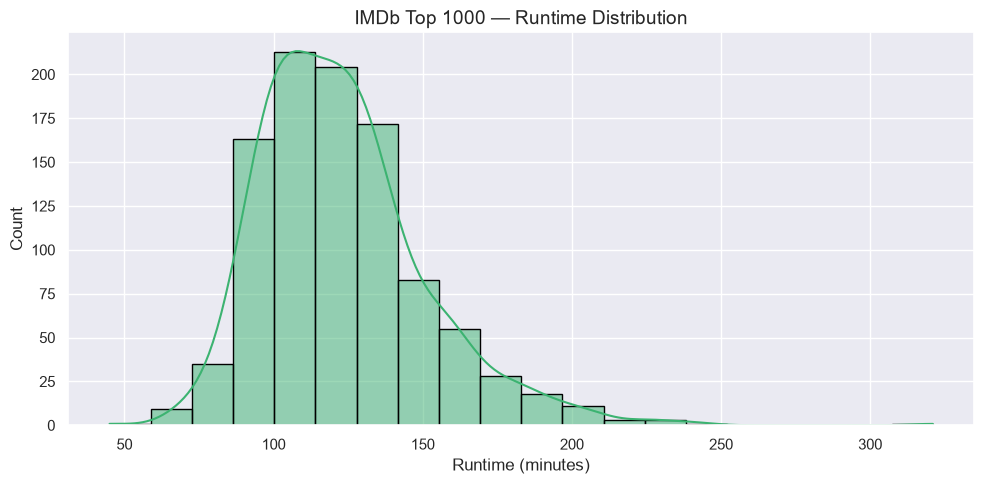

Mean Runtime    : 122.9mins
Median Runtime  : 119.0mins
Most common bin : 100mins


In [11]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("imdb_top_1000_cleaned.csv")
sns.set_theme(style='darkgrid')
fig, ax=plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x='Runtime', bins=20, kde=True, color='mediumseagreen', edgecolor='black', ax=ax)
ax.set_title('IMDb Top 1000 — Runtime Distribution', fontsize=14)
ax.set_xlabel('Runtime (minutes)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
print(f"Mean Runtime    : {df['Runtime'].mean():.1f}mins")
print(f"Median Runtime  : {df['Runtime'].median():.1f}mins")
print(f"Most common bin : {df['Runtime'].mode()[0]}mins")

---
# ***Exercise 2 — Heatmap: which two features are most correlated?***
---

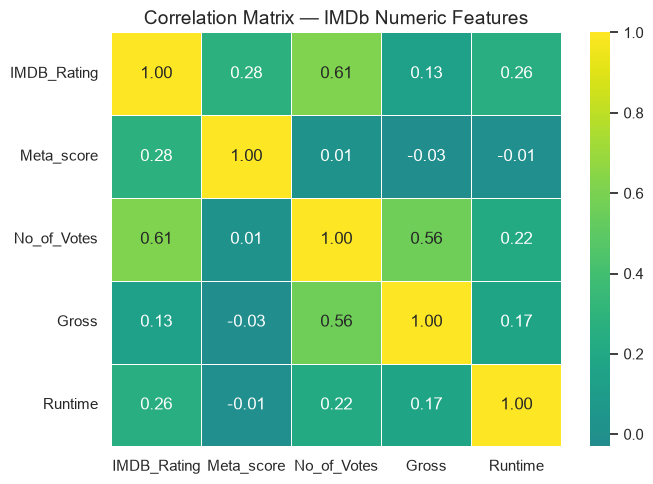

Top 3 strongest correlations in this dataset:
  Feature_A   Feature_B  Correlation
IMDB_Rating No_of_Votes     0.614111
No_of_Votes       Gross     0.555461
IMDB_Rating  Meta_score     0.282690


In [21]:
numeric_cols = df[['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross', 'Runtime']].dropna()
corr_matrix = numeric_cols.corr()
fig, ax=plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='viridis', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — IMDb Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()
corr_pairs = (corr_matrix.unstack().reset_index().rename(columns={'level_0': 'Feature_A', 'level_1': 'Feature_B', 0: 'Correlation'}))
corr_pairs = corr_pairs[corr_pairs['Feature_A'] != corr_pairs['Feature_B']]
corr_pairs['Abs'] = corr_pairs['Correlation'].abs()
corr_pairs = corr_pairs.sort_values('Abs', ascending=False).drop_duplicates(subset='Abs')
print("Top 3 strongest correlations in this dataset:")
print(corr_pairs[['Feature_A', 'Feature_B', 'Correlation']].head(3).to_string(index=False))

---
# ***Exercise 3 — Boxplot: which genre has the highest median?***
---

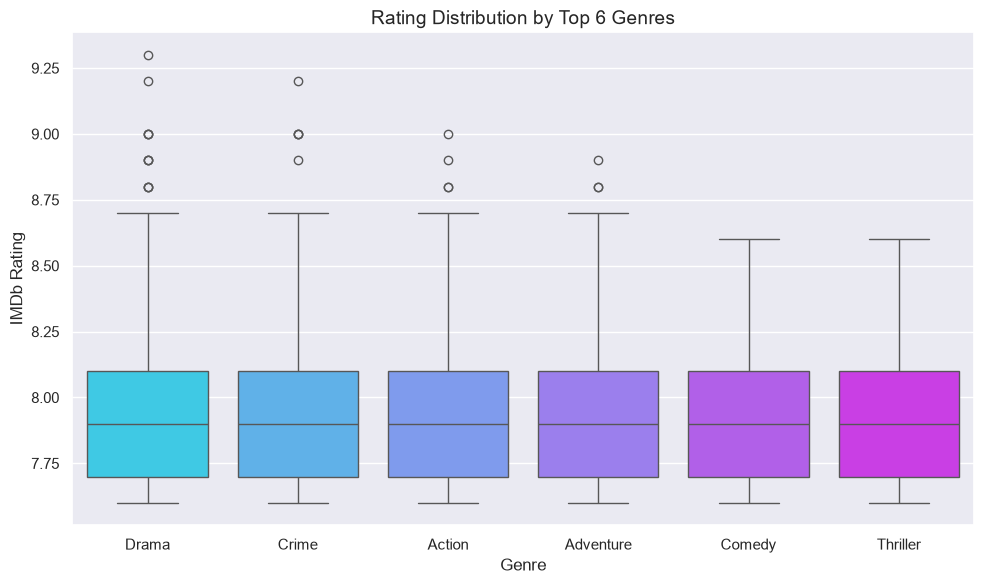

Median IMDb Rating by Genre (Top 6):
Genre
Action       7.9
Adventure    7.9
Comedy       7.9
Crime        7.9
Drama        7.9
Thriller     7.9

Highest median : Action (7.90)


In [24]:
df_genres = df.assign(Genre=df['Genre'].str.split(', ')).explode('Genre')
top_genres = df_genres['Genre'].value_counts().head(6).index
df_top = df_genres[df_genres['Genre'].isin(top_genres)]
fig, ax=plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_top, x='Genre', y='IMDB_Rating', hue='Genre', palette='cool', legend=False, ax=ax)
ax.set_title('Rating Distribution by Top 6 Genres',fontsize=14)
ax.set_xlabel('Genre')
ax.set_ylabel('IMDb Rating')
plt.tight_layout()
plt.show()
medians = df_top.groupby('Genre')['IMDB_Rating'].median().sort_values(ascending=False)
print("Median IMDb Rating by Genre (Top 6):")
print(medians.to_string())
print(f"\nHighest median : {medians.index[0]} ({medians.iloc[0]:.2f})")